In this notebook we will duplicate the results of the previous notebook, but in this case we will keep in mind the FAIR principles. We have placed the necessary code under the `models/model_01_CDMS-LR` directory. You can see the directory contains multiple subdirectories. This subdirectory structure is pretty common for ML repositories. The `data` subdirectory is used to locally store the data which in this case just refers to a symlink to the top level `data` dirctory for this project. The `src` subdirectory contains necessary code, in this case split across two files-

- **DataUtils.py**: Contains necessary code to load, split, and normalize the dataset
- **model.py**: Contains code to create and fit the desired model as well as perform some evaluation

You can also see some other files there which we will describe later, as we generate them. First, let's train our model.

In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append('../src/models/model_01_CDMS-LR/src')
from sklearn.experimental import enable_halving_search_cv 
from DataUtils import CDMS_DataLoader as DL
from model import CDMS_LR

In [4]:
import os
print(os.getcwd())

d:\GT\Courses\06-DL\Project\FAIR-UMN-CDMS\Exercises


In [ ]:
## Get the dataset as numpy array

all_augmented = [
    './data/reduced_data.csv',
    './data/reduced-augmented_shot1e-09_pink7e-08_brown3e-07_snr17.85.csv',
    './data/reduced-augmented_shot5e-09_pink2e-08_brown8e-08_snr15.58.csv',
]

myDL = DL(all_augmented, with_amp=True, sep=',')

X_train, X_test, y_train, y_test = myDL.split_data(split_type='label', labels = [-12.502, -29.500, -41.900])
X_train, X_test, y_train, y_test, x_mean, x_std = myDL.normalize_data(X_train, X_test, y_train, y_test)
y_norm = myDL.y_norm

In [4]:
print(f"Overall Shape: {myDL.data.shape}")
print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.data.shape}")

Overall Shape: (7151, 87)
Train Shape: (5636, 85)
Test Shape: (1515, 85)


RMSE from train data = 1.1027118536099667
Overall RMSE from test data = 2.688087257340602
RMSE for y = -12.5020: 1.2776
RMSE for y = -29.5000: 1.1749
RMSE for y = -41.9000: 4.4043


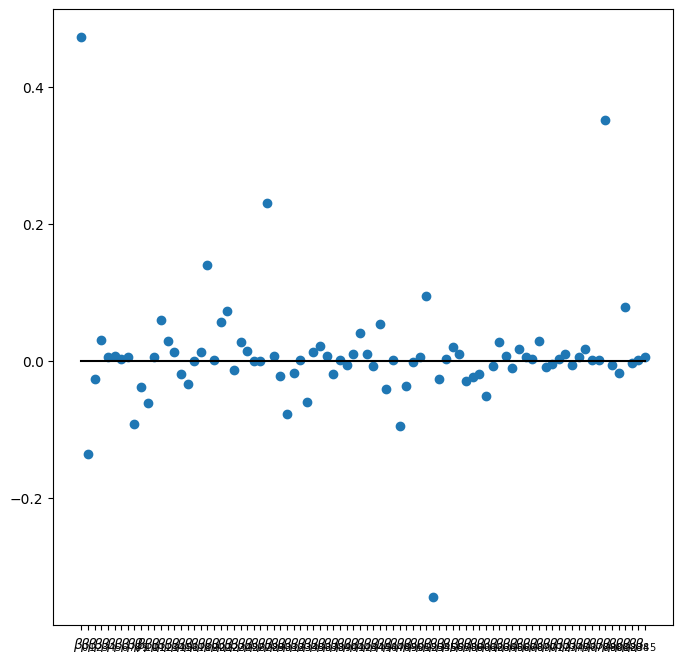

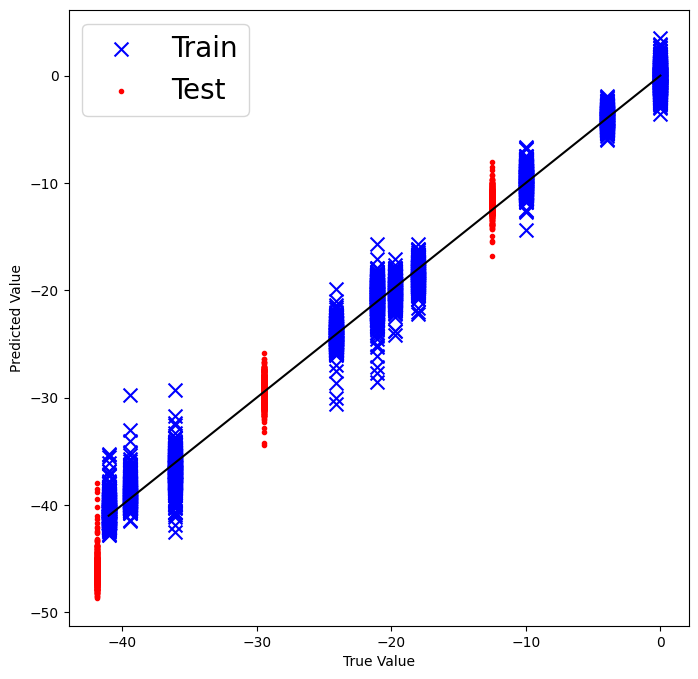

In [ ]:
lr = CDMS_LR(X_train, y_train, X_test, y_test, x_mean, x_std, y_norm, mode="LR")
lr.do_LR()
rmse_lr_train, rmse_lr_test, coeffs_opt_LR = lr.model_eval()

Let's also perform the hyperparameter scan for Ridge and Lasso Regression, the same way we did that in the previous notebook.

d:\anaconda3\envs\fair_gpu_z\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.968e+00, tolerance: 6.432e-02
  model = cd_fast.enet_coordinate_descent(
d:\anaconda3\envs\fair_gpu_z\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.939e+00, tolerance: 6.432e-02
  model = cd_fast.enet_coordinate_descent(
d:\anaconda3\envs\fair_gpu_z\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.893e+

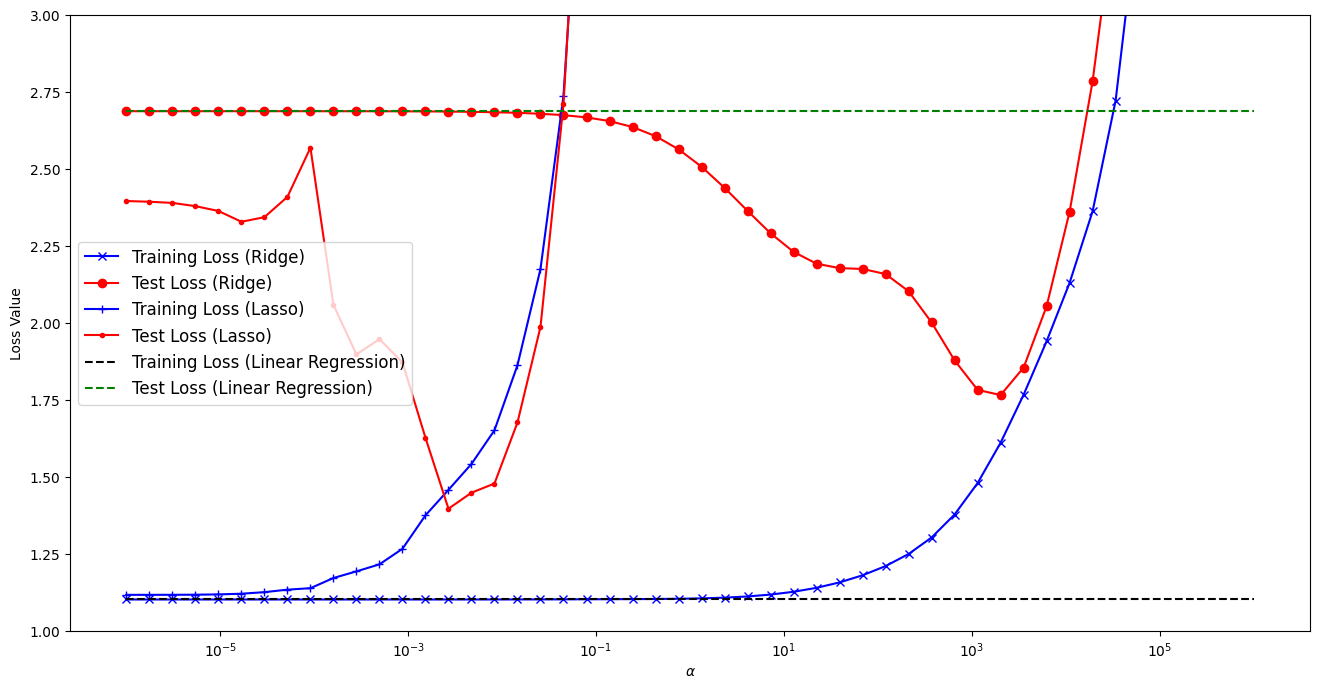

Minimum Test Loss for Ridge:  1.7664236528867248
Alpha for Minimum Test Loss for Ridge:  2023.5896477251556
Minimum Test Loss for Lasso:  1.3974697279860209
Alpha for Minimum Test Loss for Lasso:  0.0026826957952797246

 BEST RIDGE MODEL
RMSE from train data = 1.611595779117337
Overall RMSE from test data = 1.7664236528867248
RMSE for y = -12.5020: 2.4285
RMSE for y = -29.5000: 1.6508
RMSE for y = -41.9000: 1.1741


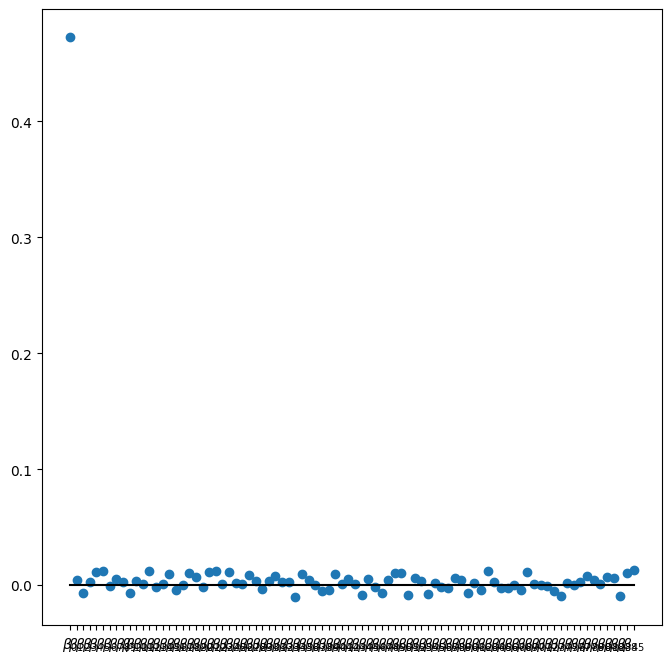

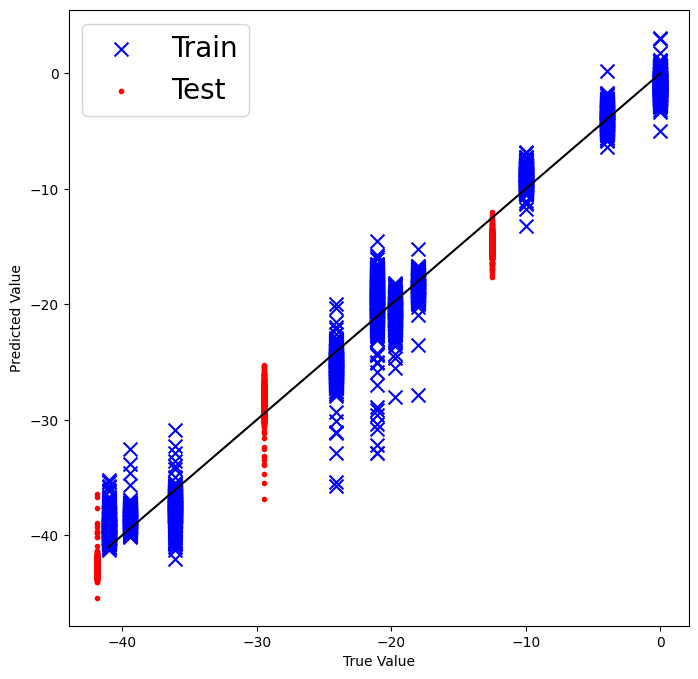


 BEST LASSO MODEL
RMSE from train data = 1.4586618512637033
Overall RMSE from test data = 1.3974697279860209
RMSE for y = -12.5020: 1.7475
RMSE for y = -29.5000: 1.2622
RMSE for y = -41.9000: 1.2359


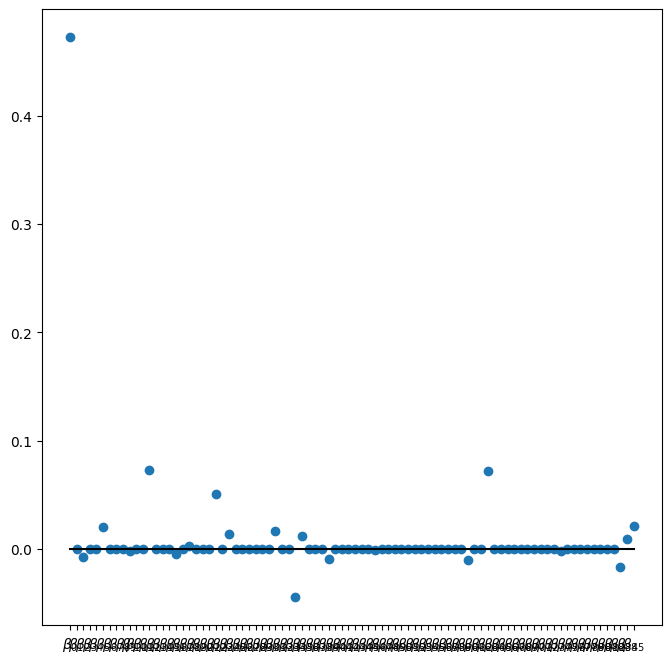

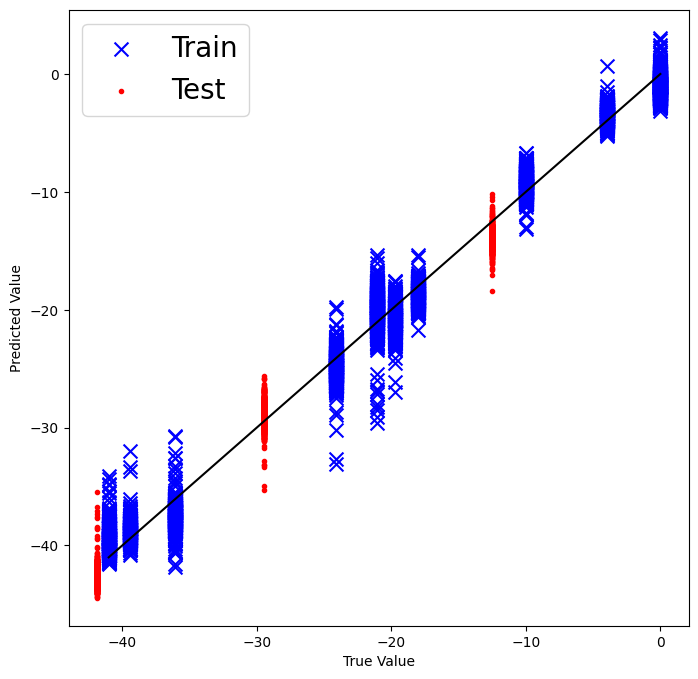

(np.float64(1.4586618512637033),
 np.float64(1.3974697279860209),
 array([ 0.47252899,  0.        , -0.00694112,  0.        ,  0.        ,
         0.02068759, -0.        ,  0.        ,  0.        , -0.00153402,
         0.        , -0.        ,  0.07269292, -0.        , -0.        ,
         0.        , -0.00438323,  0.        ,  0.00309416,  0.        ,
        -0.        ,  0.        ,  0.05045994, -0.        ,  0.01361864,
         0.        , -0.        ,  0.        ,  0.        , -0.        ,
         0.        ,  0.01638722,  0.        ,  0.        , -0.04443624,
         0.01225168,  0.        , -0.        , -0.        , -0.00893874,
         0.        , -0.        ,  0.        ,  0.        , -0.        ,
         0.        , -0.00061874, -0.        ,  0.        ,  0.        ,
         0.        , -0.        ,  0.        ,  0.        , -0.        ,
         0.        , -0.        , -0.        ,  0.        ,  0.        ,
        -0.00969962,  0.        , -0.        ,  0.07174962

In [6]:
alphas = np.logspace(-6, +6, 50)
RMSE_train_Ridge = []
RMSE_test_Ridge = []
RMSE_train_Lasso = []
RMSE_test_Lasso = []
min_ridge_loss = 99.0
min_lasso_loss = 99.0
alpha_opt_ridge = 0.
alpha_opt_lasso = 0.
coeffs_opt_ridge = []
coeffs_opt_lasso = []

for ii, alpha in enumerate(alphas):
    lr = CDMS_LR(X_train, y_train, X_test, y_test, x_mean, x_std, y_norm, mode="Ridge", alpha=alpha)
    lr.do_LR()
    etr, etst, coeffs = lr.model_eval(do_plot=False)
    RMSE_train_Ridge.append(etr)
    RMSE_test_Ridge.append(etst)
    if etst < min_ridge_loss:
        min_ridge_loss = etst
        alpha_opt_ridge = alpha
        coeffs_opt_ridge = coeffs

    lr = CDMS_LR(X_train, y_train, X_test, y_test, x_mean, x_std, y_norm, mode="Lasso", alpha=alpha)
    lr.do_LR()
    etr, etst, coeffs = lr.model_eval(do_plot=False)
    RMSE_train_Lasso.append(etr)
    RMSE_test_Lasso.append(etst)
    if etst < min_lasso_loss:
        min_lasso_loss = etst
        alpha_opt_lasso = alpha
        coeffs_opt_lasso = coeffs



fig = plt.figure(figsize=(16,8))
plt.plot(alphas, RMSE_train_Ridge, marker='x', color='b', label='Training Loss (Ridge)')
plt.plot(alphas, RMSE_test_Ridge, marker='o',  color='r', label='Test Loss (Ridge)')
plt.plot(alphas, RMSE_train_Lasso, marker='+', color='b', label='Training Loss (Lasso)')
plt.plot(alphas, RMSE_test_Lasso, marker='.', color='r', label='Test Loss (Lasso)')

plt.plot(alphas, [rmse_lr_train]*len(alphas), color='k', linestyle='--', label='Training Loss (Linear Regression)')
plt.plot(alphas, [rmse_lr_test]*len(alphas), color='g', linestyle = '--', label='Test Loss (Linear Regression)')

plt.xscale('log')
plt.xlabel(r'$\alpha$')
plt.ylabel("Loss Value")
plt.legend(fontsize = 12)
plt.ylim([1.0, 3.0])
plt.show()

print("Minimum Test Loss for Ridge: ", min_ridge_loss)
print("Alpha for Minimum Test Loss for Ridge: ", alpha_opt_ridge)

print("Minimum Test Loss for Lasso: ", min_lasso_loss)
print("Alpha for Minimum Test Loss for Lasso: ", alpha_opt_lasso)

print("\n BEST RIDGE MODEL")
best_ridge = CDMS_LR(X_train, y_train, X_test, y_test, x_mean, x_std, y_norm, mode="Ridge", alpha=alpha_opt_ridge)
best_ridge.do_LR()
best_ridge.model_eval(do_plot=True)

print("\n BEST LASSO MODEL")
best_lasso = CDMS_LR(X_train, y_train, X_test, y_test, x_mean, x_std, y_norm, mode="Lasso", alpha=alpha_opt_lasso)
best_lasso.do_LR()
best_lasso.model_eval(do_plot=True)

In principle, the codeblocks above should become a part of the model repository. However, we are demonstrating them separately in this notebook for demonstration purposes. You can see that the `src` subdirectory also has a script `trainNsave.py` which performs the exact same job as shown in the code above, as well as some of the things we show below. 

Now, we want to *publish* the trained models we have at hand, i.e. we want to make them available in a way so that an external user can directly use them without retraining them. Since we are dealing with a rather simple model here where the most complicated data structure is essentially a numpy array. Hence, we can simply store the relevant model information as dictionary type object in a **JSON** file, which is both human and machine readable.

In [6]:
import json

model_info ={}

model_info['normalization'] = {'x_mean':list(x_mean), 
                               'x_std':list(x_std), 
                               'y_norm':y_norm}
model_info['test_data'] = {'labels':[-12.502, -29.5, -41.9]}
model_info['Linear_Regression']={'coeffs':list(coeffs_opt_LR)}
model_info['Ridge_Regression'] ={'alpha':alpha_opt_ridge,
                                 'coeffs':list(coeffs_opt_ridge)}
model_info['Lasso_Regression'] ={'alpha':alpha_opt_lasso,
                                 'coeffs':list(coeffs_opt_lasso)}

json.dump(model_info, open("../src/models/model_01_CDMS-LR/model-info.json","w"), indent=3)

The codeblock above dumps a number of relevant information for the models we want to save. For someone who wants to use this model to make an inference should be able to use this information to perform all the necessary tasks- from data normalization to model predictions. However, publishing the model alone is not enough! We need relevant metadata, descriptive information about what the model is doing, what different keywords in the published trained model indicate. We can do it in a separate JSON file.

In [7]:
model_metadata = {}

model_metadata['genInfo'] = '''
This set of models represents the trained parameters for a Linear Regression model for determining the impact location on a superCDMS prototype based on timing measurements. 
'''
model_metadata['data_ID']  = 'https://github.com/FAIR-UMN/FAIR-UMN-CDMS/blob/main/data/processed_csv/processed_combined.csv?raw=true'
model_metadata['model_ID'] = ''
model_metadata['keywords'] = [key for key in model_info.keys()]
model_metadata['model_keys'] = {
    'normalization':{
        'description': 'Vectors for data standardization',
        'entries':{'x_mean': 'Mean value of input features',
                   'x_std':  'St. deviation of input features',
                   'y_norm': 'Normalization constant for target variable'
                  }
    },
    'test_data':{
        'description': 'How the test_data has been isolated',
        'entries':{'labels': 'Data label for target variable to separate test dataset'
                  }
    },
    'Linear_Regression':{
        'description': 'Model parameters for a simple linear least squared model',
        'entries':{'coeffs': 'List of linear coefficients for input features, the first entry represents the intercept'
                  }
    },
    'Ridge_Regression':{
        'description': 'Model parameters for a linear least squared model with Ridge regularization',
        'entries':{'coeffs': 'List of linear coefficients for input features, the first entry represents the intercept',
                   'alpha': 'Value of regularization strength determining model hyperparameter'
                  }
    },
    'Lasso_Regression':{
        'description': 'Model parameters for a linear least squared model with Lasso regularization',
        'entries':{'coeffs': 'List of linear coefficients for input features, the first entry represents the intercept',
                   'alpha': 'Value of regularization strength determining model hyperparameter'
                  }
    },
}

json.dump(model_metadata, open("../src/models/model_01_CDMS-LR/model-metadata.json","w"), indent=3)

Please note the design of the metadata, which besides providing a generic description of the model also gives necessary Identifiers for the model and the dataset associated with it. For this pedagogical exercise, the identifiers we are using are URLs for github repositories. However, in any application they should be replaced by more persisent URIs as we discussed in previous notebooks. Also, the metadata has a key called `model_keys` that lists the exact dictionary keys of the trained model in `model-info.json`. Each entry under this keyword is also a dictionary with keys identical to the ones available in the model info file. This is to enable a directly machine readable interface for the trained models by allowing the necessary keys from metadata.

All of this is made available via the `trainNsave.py` script in the model directory. You can run the script directly to train the model, as well as save the trained models and the corresponding metadata. To run that script from the current notebook, we use the following codeblock.

d:\GT\Courses\06-DL\Project\FAIR-UMN-CDMS\Exercises
d:\GT\Courses\06-DL\Project\FAIR-UMN-CDMS\src\models\model_01_CDMS-LR\src
Current wd of trainNsave.py: d:\GT\Courses\06-DL\Project\FAIR-UMN-CDMS\src\models\model_01_CDMS-LR\src
RMSE from train data = 1.1027118536099667
Overall RMSE from test data = 2.688087257340602
RMSE for y = -12.5020: 1.2776
RMSE for y = -29.5000: 1.1749
RMSE for y = -41.9000: 4.4043
['$\\beta_{0}$', '$\\beta_{1}$', '$\\beta_{2}$', '$\\beta_{3}$', '$\\beta_{4}$', '$\\beta_{5}$', '$\\beta_{6}$', '$\\beta_{7}$', '$\\beta_{8}$', '$\\beta_{9}$', '$\\beta_{10}$', '$\\beta_{11}$', '$\\beta_{12}$', '$\\beta_{13}$', '$\\beta_{14}$', '$\\beta_{15}$', '$\\beta_{16}$', '$\\beta_{17}$', '$\\beta_{18}$', '$\\beta_{19}$', '$\\beta_{20}$', '$\\beta_{21}$', '$\\beta_{22}$', '$\\beta_{23}$', '$\\beta_{24}$', '$\\beta_{25}$', '$\\beta_{26}$', '$\\beta_{27}$', '$\\beta_{28}$', '$\\beta_{29}$', '$\\beta_{30}$', '$\\beta_{31}$', '$\\beta_{32}$', '$\\beta_{33}$', '$\\beta_{34}$', '$\\b

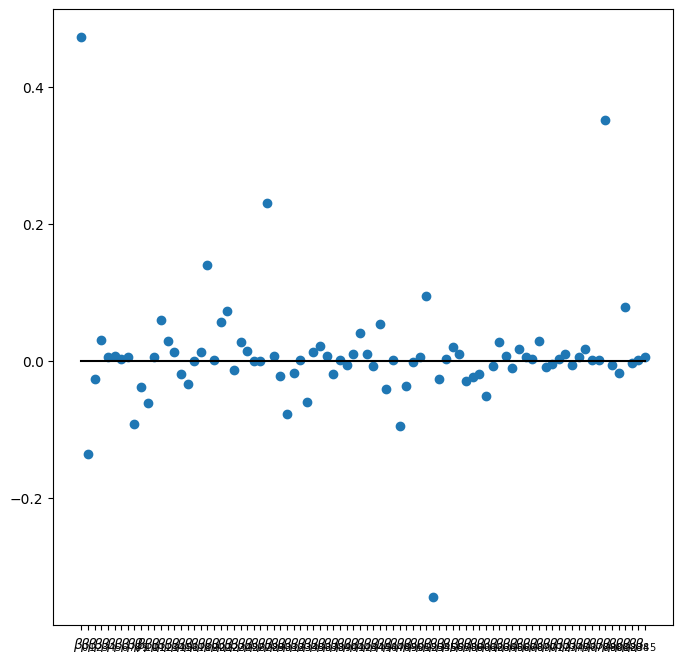

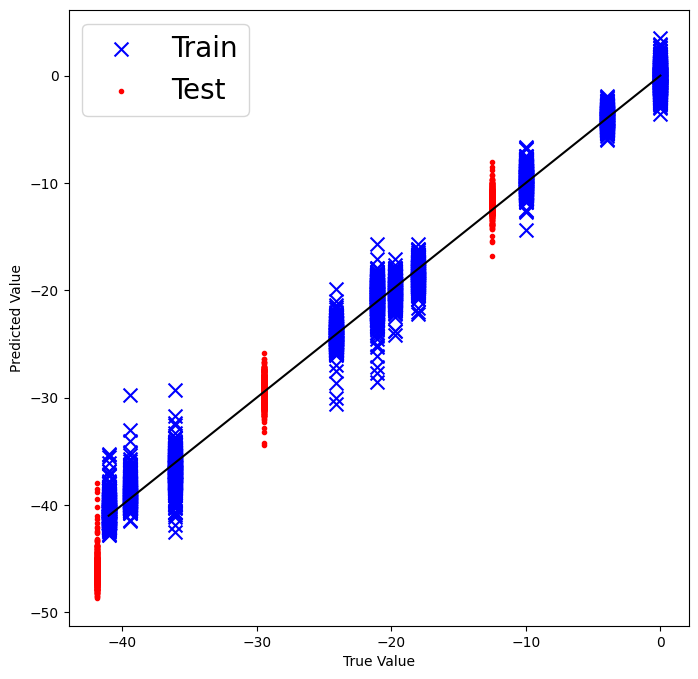

d:\anaconda3\envs\fair_gpu_z\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.968e+00, tolerance: 6.432e-02
  model = cd_fast.enet_coordinate_descent(
d:\anaconda3\envs\fair_gpu_z\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.939e+00, tolerance: 6.432e-02
  model = cd_fast.enet_coordinate_descent(
d:\anaconda3\envs\fair_gpu_z\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.893e+

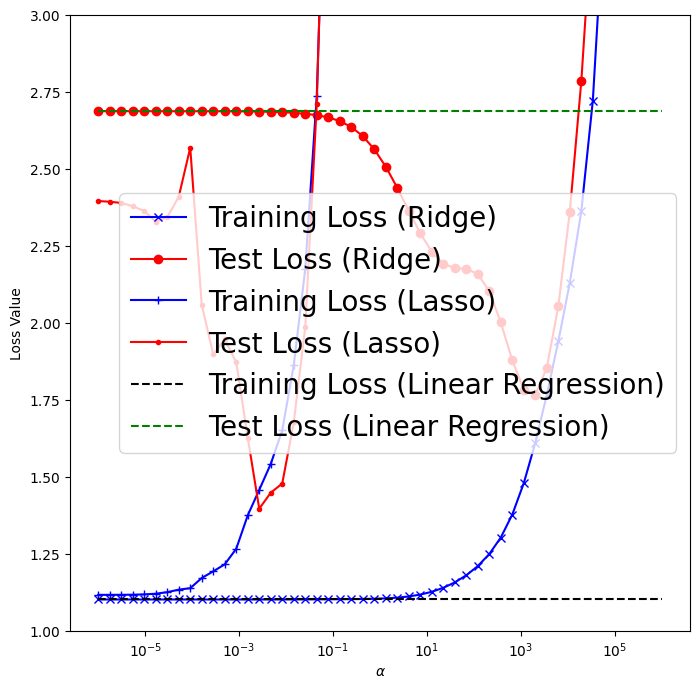

Minimum Test Loss for Ridge:  1.7664236528867248
Alpha for Minimum Test Loss for Ridge:  2023.5896477251556
Minimum Test Loss for Lasso:  1.3974697279860209
Alpha for Minimum Test Loss for Lasso:  0.0026826957952797246
d:\GT\Courses\06-DL\Project\FAIR-UMN-CDMS\Exercises


In [6]:
import os
cwd = os.getcwd()
print(cwd)
os.chdir('../src/models/model_01_CDMS-LR/src')
print(os.getcwd())
%run -i trainNsave.py
os.chdir(cwd)
print(os.getcwd())

Now finally, we want to have a dedicated example of *inference script*, that illustrates how to use the trained models for the purpose of running inference on some sample dataset. We put the code in the script `inference.py`. You can inspect the code there, the idea is to obtain the model parameters from the `model-info.json` file and use them to run regression.

In [14]:
cwd = os.getcwd()
os.chdir('../src/models/model_01_CDMS-LR/src')
%run -i inference.py
os.chdir(cwd)

ValueError: operands could not be broadcast together with shapes (19,) (0,) 